# LSTM Classifier


In [33]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

sys.path.append('..')
from src.data_utils import stratified_split, build_label_maps, encode_labels, build_vocab, encode_texts, make_dataloaders_from_arrays, load_pretrained_embeddings
from src.train_utils import set_seed, run_training, evaluate, compute_metrics
from src.pytorch_models import select_device

set_seed(2026)
device = select_device()
print('Device:', device)

CLASS_ORDER = ['Human', 'Google', 'Meta', 'OpenAI', 'Anthropic']

TRAIN_FRACTION = 1
MAX_VOCAB  = 20000
MAX_LEN    = 120
MIN_FREQ   = 3
EMBED_DIM  = 100   # ignorado se EMBEDDING='fasttext' (forçado a 300)
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT    = 0.3
BATCH_SIZE = 256
LR         = 1e-3
EPOCHS     = 30
PATIENCE   = 5

# 'glove' | 'fasttext' | None (aleatórios)
EMBEDDING    = 'glove'
BIDIRECTIONAL = False

Device: mps


## Dados

In [34]:
df = pd.read_csv('../data/clean_datasets/dataset_clean_final.csv')
train_df, val_df = stratified_split(df, 'text', 'label', test_size=0.2, seed=2026)

if TRAIN_FRACTION < 1.0:
    train_df = train_df.groupby('label', group_keys=False).apply(
        lambda g: g.sample(frac=TRAIN_FRACTION, random_state=2026)
    ).reset_index(drop=True)

#test_df = pd.read_csv('../../../dataset-exemplos.csv', sep=';')
test_df = pd.read_csv('../data/subm1_labels_revealed.csv', sep=';')
test_df = test_df.rename(columns={'Text': 'text', 'Label': 'label'})

print(f'Treino: {len(train_df):,} | Validação: {len(val_df):,} | Teste (prof): {len(test_df)}')

label_to_idx, idx_to_label = build_label_maps(CLASS_ORDER)
y_train = encode_labels(train_df['label'], label_to_idx)
y_val   = encode_labels(val_df['label'],   label_to_idx)
y_test  = encode_labels(test_df['label'],  label_to_idx)

vocab = build_vocab(train_df['text'], max_vocab=MAX_VOCAB, min_freq=MIN_FREQ)
print(f'Vocab size: {len(vocab):,}')

X_train = encode_texts(train_df['text'], vocab, MAX_LEN)
X_val   = encode_texts(val_df['text'],   vocab, MAX_LEN)
X_test  = encode_texts(test_df['text'],  vocab, MAX_LEN)

train_loader, val_loader = make_dataloaders_from_arrays(X_train, y_train, X_val, y_val, BATCH_SIZE)
test_loader, _           = make_dataloaders_from_arrays(X_test,  y_test,  X_test, y_test, BATCH_SIZE)

Treino: 240,000 | Validação: 60,000 | Teste (prof): 100
Vocab size: 20,000


In [35]:
if EMBEDDING is not None:
    embedding_matrix, EMBED_DIM = load_pretrained_embeddings(vocab, source=EMBEDDING, embed_dim=EMBED_DIM)
    print(f'Embedding matrix: {embedding_matrix.shape}')
else:
    embedding_matrix = None
    print(f'A usar embeddings aleatórios ({EMBED_DIM}d)')


A carregar glove-wiki-gigaword-100...
glove 100d: 19945/20000 palavras encontradas (99.7%)
Embedding matrix: torch.Size([20000, 100])


## Modelo

In [36]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout,
                 embedding_matrix=None, freeze=False, bidirectional=False):
        super().__init__()
        if embedding_matrix is not None:
            self.embedding = nn.Embedding.from_pretrained(
                embedding_matrix, freeze=freeze, padding_idx=0
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * (2 if bidirectional else 1), num_classes),
        )

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        if self.lstm.bidirectional:
            last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            last_hidden = hidden[-1]
        return self.classifier(last_hidden)


model = LSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=len(CLASS_ORDER),
    dropout=DROPOUT,
    embedding_matrix=embedding_matrix,
    freeze=False,
    bidirectional=BIDIRECTIONAL,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nParâmetros totais: {total_params:,}')

LSTMClassifier(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=5, bias=True)
  )
)

Parâmetros totais: 2,118,405


## Treino

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

mlflow_params = {
    'model': 'LSTM',
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'embed_dim': EMBED_DIM,
    'dropout': DROPOUT,
    'lr': LR,
    'batch_size': BATCH_SIZE,
    'train_fraction': TRAIN_FRACTION,
    'max_vocab': MAX_VOCAB,
    'max_len': MAX_LEN,
    'bidirectional': BIDIRECTIONAL,
    'embedding': EMBEDDING,
}

history, best_state, best_epoch = run_training(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=EPOCHS, patience=PATIENCE, verbose=True,
    mlflow_params=mlflow_params,
)

model.load_state_dict(best_state)
print(f'\nMelhor epoch: {best_epoch}')

Epoch 01/30 | train_loss=0.9147 train_acc=0.5957 | val_loss=0.4965 val_acc=0.8048
Epoch 02/30 | train_loss=0.3264 train_acc=0.8832 | val_loss=0.2368 val_acc=0.9169
Epoch 03/30 | train_loss=0.1798 train_acc=0.9399 | val_loss=0.2027 val_acc=0.9339
Epoch 04/30 | train_loss=0.1239 train_acc=0.9593 | val_loss=0.1904 val_acc=0.9380
Epoch 05/30 | train_loss=0.0939 train_acc=0.9695 | val_loss=0.1926 val_acc=0.9372
Epoch 06/30 | train_loss=0.0722 train_acc=0.9771 | val_loss=0.2015 val_acc=0.9387
Epoch 07/30 | train_loss=0.0552 train_acc=0.9829 | val_loss=0.2298 val_acc=0.9404
Epoch 08/30 | train_loss=0.0429 train_acc=0.9870 | val_loss=0.2270 val_acc=0.9406
Epoch 09/30 | train_loss=0.0346 train_acc=0.9898 | val_loss=0.2529 val_acc=0.9382
Epoch 10/30 | train_loss=0.0285 train_acc=0.9915 | val_loss=0.3015 val_acc=0.9362
Epoch 11/30 | train_loss=0.0230 train_acc=0.9935 | val_loss=0.2933 val_acc=0.9362
Epoch 12/30 | train_loss=0.0203 train_acc=0.9944 | val_loss=0.2969 val_acc=0.9377
Epoch 13/30 | tr

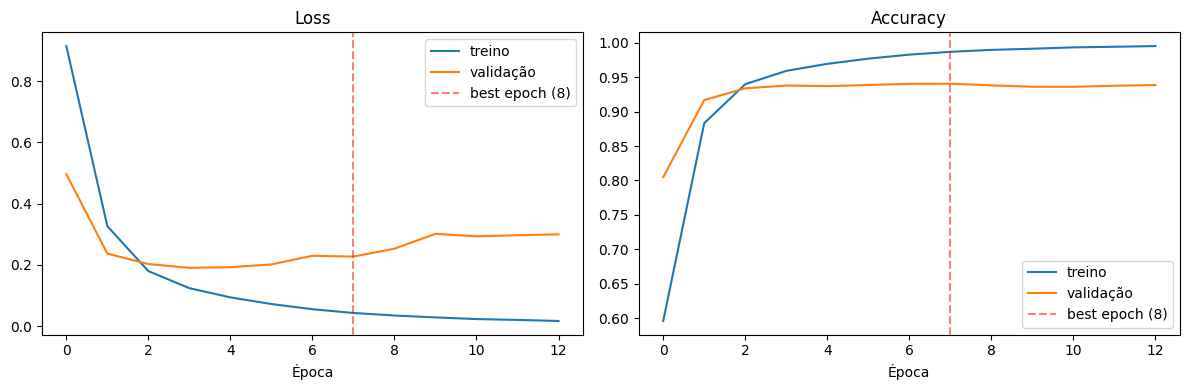

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (tr, vl, title) in zip(axes, [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_acc',  'val_acc',  'Accuracy'),
]):
    ax.plot(history[tr], label='treino')
    ax.plot(history[vl], label='validação')
    ax.axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'best epoch ({best_epoch})')
    ax.set_xlabel('Época')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

## Avaliação

In [39]:
for loader, name in [(val_loader, 'Validação (20%)'), (test_loader, 'Teste (prof)')]:
    _, _, y_true, y_pred = evaluate(model, loader, criterion, device)
    m = compute_metrics(y_true, y_pred, list(range(len(CLASS_ORDER))))
    print(f'\n=== {name} ===')
    print(f'Accuracy: {m["accuracy"]:.4f} | Macro F1: {m["macro_f1"]:.4f}')
    print(m['report'])


=== Validação (20%) ===
Accuracy: 0.9406 | Macro F1: 0.9407
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     12000
           1       0.93      0.94      0.94     12000
           2       0.94      0.92      0.93     12000
           3       0.92      0.94      0.93     12000
           4       0.97      0.95      0.96     12000

    accuracy                           0.94     60000
   macro avg       0.94      0.94      0.94     60000
weighted avg       0.94      0.94      0.94     60000


=== Teste (prof) ===
Accuracy: 0.3700 | Macro F1: 0.3288
              precision    recall  f1-score   support

           0       0.89      0.50      0.64        34
           1       0.38      0.18      0.24        17
           2       0.67      0.11      0.19        18
           3       0.09      0.21      0.13        14
           4       0.32      0.71      0.44        17

    accuracy                           0.37       100
   macro avg

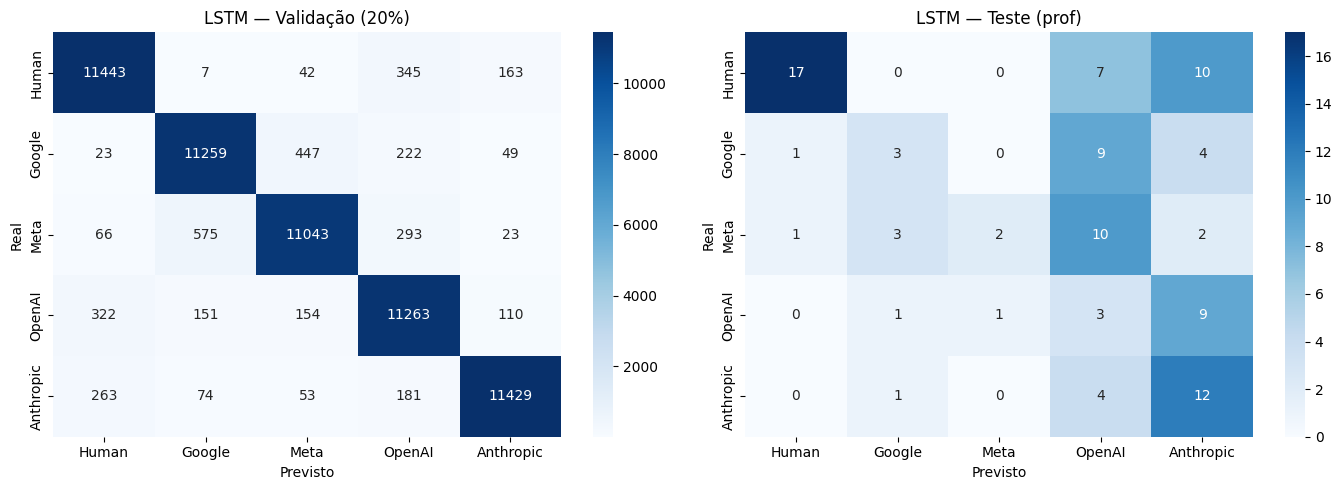

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (loader, name) in zip(axes, [(val_loader, 'Validação (20%)'), (test_loader, 'Teste (prof)')]):
    _, _, y_true, y_pred = evaluate(model, loader, criterion, device)
    m = compute_metrics(y_true, y_pred, list(range(len(CLASS_ORDER))))
    sns.heatmap(m['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_title(f'LSTM — {name}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

## Guardar

In [41]:
import os, pickle
os.makedirs('../modelos', exist_ok=True)

torch.save({
    'state_dict': best_state,
    'vocab': vocab,
    'max_len': MAX_LEN,
    'class_order': CLASS_ORDER,
    'label_to_idx': label_to_idx,
    'config': {
        'embed_dim': EMBED_DIM, 'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS, 'dropout': DROPOUT,
    }
}, '../modelos/lstm.pt')
print('Guardado em ../modelos/lstm.pt')

Guardado em ../modelos/lstm.pt
